# 本福特定律

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib widget

plt.rcParams['font.family'] = 'Arial Unicode MS'  # macOS 专用中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 加载kaggle数据集

In [2]:
# 下载kaggle人口数据
path = kagglehub.dataset_download("iamsouravbanerjee/world-population-dataset")
path = os.path.join(path, "world_population.csv")
print("Path to dataset files:", path)

Path to dataset files: /Users/yangguandao/.cache/kagglehub/datasets/iamsouravbanerjee/world-population-dataset/versions/4/world_population.csv


## 清洗数据、检查数据

In [3]:
#读取CSV文件
df = pd.read_csv(path)

# 数据预处理
# 选择需要的列并重命名
df = df[['Country/Territory', '2022 Population', 'Area (km²)']].copy()
df.columns = ['Country', 'Population', 'Area']

# 清洗数据：移除缺失值和0值
df = df.dropna(subset=['Population', 'Area'])
df = df[(df['Population'] > 0) & (df['Area'] > 0)]

pd.set_option('display.float_format', lambda x: '%.1f' % x)
print("--------describe--------\n")
print(df.describe())
print("--------columns--------\n")
print(df.columns)
print("--------dtypes--------\n")
print(df.dtypes)

--------describe--------

        Population       Area
count        234.0      234.0
mean    34074414.7   581449.4
std    136766424.8  1761840.9
min          510.0        1.0
25%       419738.5     2650.0
50%      5559944.5    81199.5
75%     22476504.8   430425.8
max   1425887337.0 17098242.0
--------columns--------

Index(['Country', 'Population', 'Area'], dtype='object')
--------dtypes--------

Country       object
Population     int64
Area           int64
dtype: object


In [4]:
# 获取首位数字的函数
def get_first_digit(number):
    num_str = str(number).lstrip('0').replace('.', '')  # 去除前导0和小数点
    if num_str == '':
        return None
    return int(num_str[0])  # 返回第一个数字

# 测试，应该打印7
print(get_first_digit(72829))

7


In [5]:
# 应用函数获取首位数字
df['Population_First_Digit'] = df['Population'].apply(get_first_digit)
df['Area_First_Digit'] = df['Area'].apply(get_first_digit)

# 过滤无效数字（1-9）
df = df[(df['Population_First_Digit'] >= 1) & (df['Population_First_Digit'] <= 9)]
df = df[(df['Area_First_Digit'] >= 1) & (df['Area_First_Digit'] <= 9)]

print("--------describe--------\n")
print(df.describe())

--------describe--------

        Population       Area  Population_First_Digit  Area_First_Digit
count        234.0      234.0                   234.0             234.0
mean    34074414.7   581449.4                     3.4               3.4
std    136766424.8  1761840.9                     2.4               2.5
min          510.0        1.0                     1.0               1.0
25%       419738.5     2650.0                     1.0               1.0
50%      5559944.5    81199.5                     3.0               3.0
75%     22476504.8   430425.8                     5.0               5.0
max   1425887337.0 17098242.0                     9.0               9.0


## 画图-人口的首位数字分布

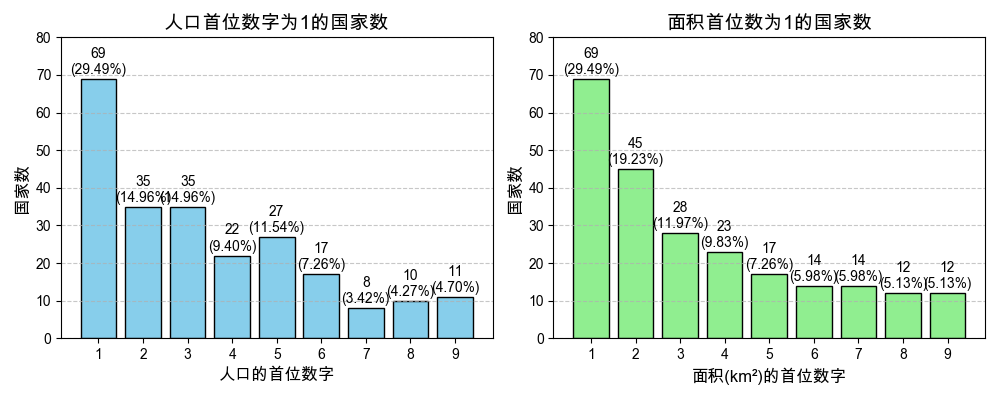

In [6]:
# 创建画布
plt.figure(figsize=(10, 4))

# 图1：人口首位数字分布
plt.subplot(1, 2, 1)
pop_counts = df['Population_First_Digit'].value_counts().sort_index()
plt.bar(pop_counts.index, pop_counts.values, color='skyblue', edgecolor='black')
plt.title('人口首位数字为1的国家数', fontsize=14)
plt.xlabel('人口的首位数字', fontsize=12)
plt.ylabel('国家数', fontsize=12)
plt.xticks(range(1, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 90, 10))

total = pop_counts.sum()

# 添加数值标签
for i, count in enumerate(pop_counts.values):
    plt.text(pop_counts.index[i], count + 0.5, str(count)+f"\n({count*100/total:.2f}%)", 
             ha='center', va='bottom', fontsize=10)

# 图2：面积首位数字分布
plt.subplot(1, 2, 2)
area_counts = df['Area_First_Digit'].value_counts().sort_index()
plt.bar(area_counts.index, area_counts.values, color='lightgreen', edgecolor='black')
plt.title('面积首位数为1的国家数', fontsize=14)
plt.xlabel('面积(km²)的首位数字', fontsize=12)
plt.ylabel('国家数', fontsize=12)
plt.xticks(range(1, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 90, 10))

# 添加数值标签
for i, count in enumerate(area_counts.values):
    plt.text(area_counts.index[i], count + 0.5, str(count)+f"\n({count*100/total:.2f}%)", 
             ha='center', va='bottom', fontsize=10)

# 调整布局并显示
plt.tight_layout()
plt.show()

## 画图-人口分布

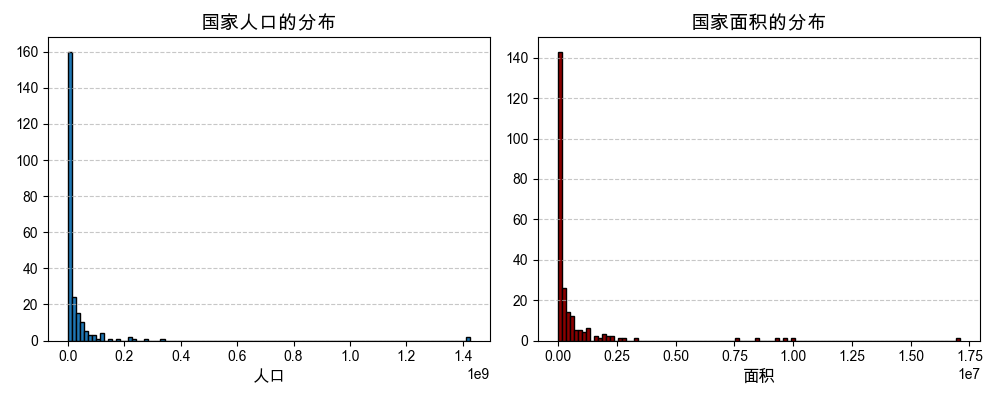

In [7]:
# 创建画布
plt.figure(figsize=(10, 4))

# 图1：国家人口分布
plt.subplot(1,2,1)
plt.hist(df['Population'], bins=100, edgecolor='black')
plt.title('国家人口的分布', fontsize=14)
plt.xlabel('人口', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 图2：国家面积分布
plt.subplot(1,2,2)
plt.hist(df['Area'], bins=100, color='darkred', edgecolor='black')
plt.title('国家面积的分布', fontsize=14)
plt.xlabel('面积', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 调整布局并显示
plt.tight_layout()
plt.show()

## 画图-人口的对数分布

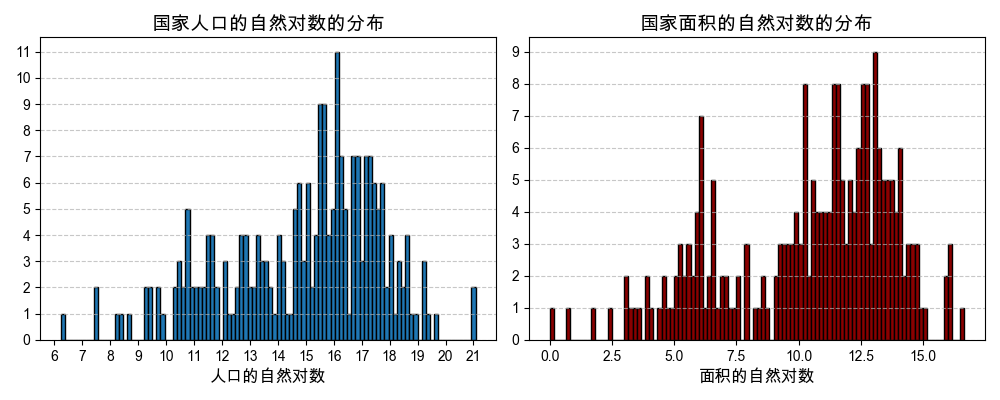

In [8]:
# 创建画布
plt.figure(figsize=(10, 4))

# 图1：国家人口对数分布
plt.subplot(1,2,1)
plt.hist(np.log(df['Population']), bins=100, edgecolor='black')
plt.title('国家人口的自然对数的分布', fontsize=14)
plt.xlabel('人口的自然对数', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(6, 22))
plt.yticks(range(0, 12))

# 图2：国家面积对数分布
plt.subplot(1,2,2)
plt.hist(np.log(df['Area']), bins=100, color='darkred', edgecolor='black')
plt.title('国家面积的自然对数的分布', fontsize=14)
plt.xlabel('面积的自然对数', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(range(0, 10))

# 调整布局并显示
plt.tight_layout()
plt.show()

## 总结
像人口、国土面积这样的指标的增长是指数级的，而不是线性的，所以其分布遵循幂律分布。于是对其取对数查看分布情况是常用的分析手段，往往取对数后程正态分布。   

至于人口为什么满足本福特定律，可以直观理解为：人口从1增长到2，或者从10增长到20，或者从100增长到200，比从2增长到3，或者从20增长到30，或者从200增长到300，要“难”！要“更久”!